In [1]:
import pandas as pd
import numpy as np
import re

# Load raw data
df = pd.read_csv("../data/mobile_money_statements.csv")

# Clean amount column
def clean_amount(val):
    val = str(val).strip()
    is_negative = 'Dr' in val or val.startswith('(') or val.startswith('-')
    num = re.sub(r'[^\d.]', '', val)
    num = float(num) if num else 0.0
    return -num if is_negative else num
df['amount_clean'] = df['amount'].apply(clean_amount)

# Clean txn_time column
def parse_txn_time(val):
    val = str(val).strip()
    if re.match(r'^\d{4}-\d{2}-\d{2}', val):
        return pd.to_datetime(val, format='%Y-%m-%d %H:%M:%S')
    elif re.match(r'^\d{2}/\d{2}/\d{4}', val):
        return pd.to_datetime(val, format='%d/%m/%Y %H:%M')
    else:
        return pd.to_datetime(val, format='%b %d, %Y %I:%M %p')
df['txn_time_clean'] = df['txn_time'].apply(parse_txn_time)

print(df.shape)
df.head()

(183600, 20)


,txn_id,msisdn,reg_id,account_name,region,segment,txn_time,txn_type,amount,gps_lat,gps_lon,agent_id,device_id,counterparty,balance_after,manual_review_score,settlement_status,is_fraud,amount_clean,txn_time_clean
0,TXN0102856,254700004022,NID101089,Joseph Mwangi,Kampala,retail,2026-06-30 14:24:19,send,"1,329/- Dr",NaN,NaN,AG1014,DV978723,CP6324,8123.0,0.061,settled,0,-1329.0,2026-06-30 14:24:19
1,TXN0155490,254700013612,NID103658,Rehema Ndlovu,Mombasa,retail,"Jan 29, 2026 01:17 PM",send,289/- Dr,1.77470,34.70915,AG1084,DV616667,CP2831,6322.0,0.000,settled,0,-289.0,2026-01-29 13:17:00
2,TXN0019434,254700005862,nid101584,Mary Mutua,Arusha,retail,"Sep 16, 2025 12:55 AM",receive,"1,571/-",-3.74336,33.67018,AG1091,DV637734,CP167,15237.0,0.912,reversed,1,1571.0,2025-09-16 00:55:00
3,TXN0049426,254700009223,NID102493,Joseph Okoth,Dar es Salaam,retail,07/04/2026 11:21,send,599/- Dr,NaN,NaN,AG1047,DV666470,CP3382,3322.0,0.095,settled,0,-599.0,2026-04-07 11:21:00
4,TXN0013816,254700014760,nid103963,B. Ssentongo,Mwanza,retail,20/12/2025 11:05,cashout,"(1,307/-)",0.08284,29.02835,NaN,NaN,CP8428,2168.0,0.085,settled,0,-1307.0,2025-12-20 11:05:00


In [2]:
# OUTPUT FOR ASSIGNMENT I

# ============================================
# RFM FEATURES
# ============================================
freq = df.groupby('msisdn').size()
rfm = pd.DataFrame({'msisdn': freq.index, 'frequency': freq.values})

last_txn = df.groupby('msisdn')['txn_time_clean'].max()
reference_date = df['txn_time_clean'].max()
recency = (reference_date - last_txn).dt.days
rfm['recency'] = rfm['msisdn'].map(recency)

total_volume = df.groupby('msisdn')['amount_clean'].apply(lambda x: x.abs().sum())
rfm['total_volume'] = rfm['msisdn'].map(total_volume)

net_flow = df.groupby('msisdn')['amount_clean'].sum()
rfm['net_flow'] = rfm['msisdn'].map(net_flow)

# ============================================
# RATIO FEATURES
# ============================================
inflow = df[df['amount_clean'] > 0].groupby('msisdn')['amount_clean'].sum()
outflow = df[df['amount_clean'] < 0].groupby('msisdn')['amount_clean'].apply(lambda x: x.abs().sum())

rfm['no_inflow_flag'] = (~rfm['msisdn'].isin(inflow.index)).astype(int)
outflow_inflow_ratio = outflow / inflow
rfm['outflow_inflow_ratio'] = rfm['msisdn'].map(outflow_inflow_ratio)

airtime_spend = df[df['txn_type'] == 'airtime'].groupby('msisdn')['amount_clean'].apply(lambda x: x.abs().sum())
airtime_share = (airtime_spend / outflow).fillna(0)
rfm['airtime_share'] = rfm['msisdn'].map(airtime_share)

# ============================================
# VELOCITY/TREND FEATURES
# ============================================
df_sorted = df.sort_values('txn_time_clean')
first_balance = df_sorted.groupby('msisdn')['balance_after'].first()
last_balance = df_sorted.groupby('msisdn')['balance_after'].last()
rfm['balance_trend'] = rfm['msisdn'].map(last_balance - first_balance)

ref_date = df['txn_time_clean'].max()
recent_txns = df[df['txn_time_clean'] > ref_date - pd.Timedelta(days=30)]
recent_count = recent_txns.groupby('msisdn').size()
total_days_active = (df.groupby('msisdn')['txn_time_clean'].max() - df.groupby('msisdn')['txn_time_clean'].min()).dt.days.clip(lower=1)
overall_rate_per_30d = (freq / total_days_active) * 30
rfm['txn_count_trend'] = rfm['msisdn'].map(recent_count).fillna(0) - rfm['msisdn'].map(overall_rate_per_30d)

recent_avg_amt = recent_txns.groupby('msisdn')['amount_clean'].apply(lambda x: x.abs().mean())
overall_avg_amt = df.groupby('msisdn')['amount_clean'].apply(lambda x: x.abs().mean())
rfm['amount_trend'] = rfm['msisdn'].map(recent_avg_amt).fillna(0) - rfm['msisdn'].map(overall_avg_amt)

# ============================================
# STABILITY FEATURES
# ============================================
df['week'] = df['txn_time_clean'].dt.to_period('W')
weekly_counts = df.groupby(['msisdn', 'week']).size()
weekly_count_std = weekly_counts.groupby('msisdn').std()
weeks_per_customer = weekly_counts.groupby('msisdn').size()
rfm['insufficient_history_flag'] = rfm['msisdn'].map(weeks_per_customer).eq(1).astype(int)
rfm['weekly_count_std'] = rfm['msisdn'].map(weekly_count_std).fillna(0)

rfm['distinct_counterparties'] = rfm['msisdn'].map(df.groupby('msisdn')['counterparty'].nunique())
rfm['amount_std'] = rfm['msisdn'].map(df.groupby('msisdn')['amount_clean'].apply(lambda x: x.abs().std()))

# ============================================
# BEHAVIOURAL FLAGS
# ============================================
df['hour'] = df['txn_time_clean'].dt.hour
df['is_night_txn'] = df['hour'].between(0, 5)
rfm['night_txn_share'] = rfm['msisdn'].map(df.groupby('msisdn')['is_night_txn'].mean())

print(rfm.shape)
rfm.head()

(4825, 16)


,msisdn,frequency,recency,total_volume,net_flow,no_inflow_flag,outflow_inflow_ratio,airtime_share,balance_trend,txn_count_trend,amount_trend,insufficient_history_flag,weekly_count_std,distinct_counterparties,amount_std,night_txn_share
0,254700000000,7,25,12950.0,-4016.0,0,1.899037,0.000000,-304.0,0.481481,-659.000000,0,0.000000,7,1045.925746,0.285714
1,254700000003,39,18,63583.0,-21175.0,0,1.998632,0.014276,4919.0,-1.245681,396.666667,0,0.628890,39,1206.192625,0.179487
2,254700000005,8,55,18902.0,-8296.0,0,2.564398,0.000000,1557.0,-0.522876,-2362.750000,0,0.377964,7,2303.380606,0.375000
3,254700000007,17,5,21390.0,322.0,0,0.970339,0.030473,-3449.0,0.044944,-992.235294,0,0.351866,16,980.868335,0.176471
4,254700000008,6,227,7639.0,-5083.0,0,4.977308,0.020123,-1638.0,-0.580645,-1273.166667,0,0.000000,6,1034.796872,0.333333


 # 1. EVALUATION PLAN

In [3]:
# Attach target: mark a customer as positive if ANY of their transactions was flagged as fraud
rfm['is_fraud'] = rfm['msisdn'].map(df.groupby('msisdn')['is_fraud'].max())

print("Positive rate:", rfm['is_fraud'].mean())
rfm['is_fraud'].value_counts()

Positive rate: 0.816580310880829


is_fraud
1    3940
0     885
Name: count, dtype: int64

In [4]:
# Check the ORIGINAL fraud rate at transaction level (before we aggregated to customer level)
print("Transaction-level fraud rate:", df['is_fraud'].mean())
print(df['is_fraud'].value_counts())

Transaction-level fraud rate: 0.0840359477124183
is_fraud
0    168171
1     15429
Name: count, dtype: int64


In [5]:
# Attach each customer's behavioral features to every one of their individual transactions
df_final = df.merge(rfm.drop(columns=['is_fraud']), on='msisdn', how='left')

print(df_final.shape)
df_final.head()

(183600, 38)


,txn_id,msisdn,reg_id,account_name,region,segment,txn_time,txn_type,amount,gps_lat,...,outflow_inflow_ratio,airtime_share,balance_trend,txn_count_trend,amount_trend,insufficient_history_flag,weekly_count_std,distinct_counterparties,amount_std,night_txn_share
0,TXN0102856,254700004022,NID101089,Joseph Mwangi,Kampala,retail,2026-06-30 14:24:19,send,"1,329/- Dr",NaN,...,3.643593,0.002608,-575.0,0.666667,-70.214912,0,0.780779,53,1700.960411,0.192982
1,TXN0155490,254700013612,NID103658,Rehema Ndlovu,Mombasa,retail,"Jan 29, 2026 01:17 PM",send,289/- Dr,1.77470,...,0.824301,0.000000,6159.0,0.098196,2588.666667,0,0.000000,15,1094.891297,0.400000
2,TXN0019434,254700005862,nid101584,Mary Mutua,Arusha,retail,"Sep 16, 2025 12:55 AM",receive,"1,571/-",-3.74336,...,1.253636,0.018187,-636.0,-0.778203,1966.483871,0,0.714060,31,1849.623581,0.225806
3,TXN0049426,254700009223,NID102493,Joseph Okoth,Dar es Salaam,retail,07/04/2026 11:21,send,599/- Dr,NaN,...,1.265372,0.002796,-6563.0,-0.379447,1044.017544,0,0.593748,57,1509.217881,0.245614
4,TXN0013816,254700014760,nid103963,B. Ssentongo,Mwanza,retail,20/12/2025 11:05,cashout,"(1,307/-)",0.08284,...,0.756641,0.019772,7384.0,-1.910828,-1569.500000,0,0.558796,30,1349.264953,0.200000


In [6]:
# Find the very earliest transaction date in the whole dataset
print("Earliest transaction:", df_final['txn_time_clean'].min())

# Find the very latest transaction date in the whole dataset
print("Latest transaction:", df_final['txn_time_clean'].max())

# Calculate the total number of days between the earliest and latest transaction
# This tells us how much real time our dataset actually spans
print("Total days covered:", (df_final['txn_time_clean'].max() - df_final['txn_time_clean'].min()).days)

Earliest transaction: 2025-02-06 00:46:00
Latest transaction: 2026-07-31 22:11:42
Total days covered: 540


In [7]:
# Creating a "month" label for each transaction based on its timestamp
# groups all transactions from the same calendar month together
df_final['month'] = df_final['txn_time_clean'].dt.to_period('M')

# Count how many transactions fall into each month
monthly_counts = df_final.groupby('month').size()
print(monthly_counts)

month
2025-02     7514
2025-03    10511
2025-04    10276
2025-05    10562
2025-06    10095
2025-07    10384
2025-08    10366
2025-09    10421
2025-10    10464
2025-11    10198
2025-12    10570
2026-01    10639
2026-02     9581
2026-03    10692
2026-04    10335
2026-05    10559
2026-06    10150
2026-07    10283
Freq: M, dtype: int64


In [8]:
# s sorted in proper time order first — critical for time-series splitting
df_final = df_final.sort_values('txn_time_clean').reset_index(drop=True)

# Define how many days to "purge" (remove) right at the train/test boundary,
# as a safety buffer against any subtle leakage across the line
PURGE_DAYS = 3

# Define our first test month: February 2026
test_month = pd.Period('2026-02', freq='M')

# The test set = every transaction that falls inside that specific month
test_mask = df_final['month'] == test_month
test_set = df_final[test_mask]

# The training cutoff = the very first day of the test month, minus our purge buffer
# (this pushes the training boundary a few days earlier, creating a safety gap)
test_start_date = test_month.start_time
train_cutoff = test_start_date - pd.Timedelta(days=PURGE_DAYS)

# The training set = everything that happened before that (purged) cutoff date
train_mask = df_final['txn_time_clean'] < train_cutoff
train_set = df_final[train_mask]

# Quick check: how many rows ended up in each, and confirm no overlap in dates
print("Training rows:", train_set.shape[0])
print("Training data ends:", train_set['txn_time_clean'].max())
print("Test rows:", test_set.shape[0])
print("Test data starts:", test_set['txn_time_clean'].min())

Training rows: 120962
Training data ends: 2026-01-28 23:51:00
Test rows: 9581
Test data starts: 2026-02-01 00:00:00


In [9]:
# List of the 6 months we'll test on, one at a time (rotating forward through the year)
test_months = ['2026-02', '2026-03', '2026-04', '2026-05', '2026-06', '2026-07']

# How many days to "purge" (remove) right at the train/test boundary, same as before
PURGE_DAYS = 3

# This will store each fold's train/test row-indices so they can be reused later
folds = []

# Loop through each test month one at a time
for month_str in test_months:
    # Convert the text (e.g. '2026-02') into a proper time period
    test_month = pd.Period(month_str, freq='M')

    # Test set = all rows falling inside this specific month
    test_mask = df_final['month'] == test_month
    
    # Training cutoff = start of test month, minus the purge buffer
    train_cutoff = test_month.start_time - pd.Timedelta(days=PURGE_DAYS)
    
    # Training set = everything before that purged cutoff date
    train_mask = df_final['txn_time_clean'] < train_cutoff
    
    # Save this fold's info: which month it tested on, and the row-masks for train/test
    folds.append({
        'test_month': month_str,
        'train_mask': train_mask,
        'test_mask': test_mask
    })
    
    # Print a quick summary so we can verify every fold looks sensible
    print(f"Fold testing on {month_str}: {train_mask.sum()} train rows, {test_mask.sum()} test rows")

Fold testing on 2026-02: 120962 train rows, 9581 test rows
Fold testing on 2026-03: 130498 train rows, 10692 test rows
Fold testing on 2026-04: 141259 train rows, 10335 test rows
Fold testing on 2026-05: 151645 train rows, 10559 test rows
Fold testing on 2026-06: 162114 train rows, 10150 test rows
Fold testing on 2026-07: 172320 train rows, 10283 test rows


# 2. TRAIN THE MODELS ( LOGISTIC REGRESSION, RANDOM FOREST, XG BOOST)

# 2.1 LOGISTIC REGRESSION

In [10]:
# Define which columns are actual usable features 
# Numeric features
numeric_features = [
    'amount_clean', 'balance_after',  # raw transaction-level info
    'frequency', 'recency', 'total_volume', 'net_flow',  # RFM
    'outflow_inflow_ratio', 'airtime_share',  # ratios
    'balance_trend', 'txn_count_trend', 'amount_trend',  # velocity/trend
    'weekly_count_std', 'distinct_counterparties', 'amount_std',  # stability
    'night_txn_share'  # behavioural
]

# Categorical features
categorical_features = ['txn_type', 'segment', 'region']

# The target we are predicting
target = 'is_fraud'

# manual_review_score and settlement_status are deliberately excluded here,
# since Assignment 1 proved they leak the label directly (AUC of 1.0 when included)

print(numeric_features)
print(categorical_features)

['amount_clean', 'balance_after', 'frequency', 'recency', 'total_volume', 'net_flow', 'outflow_inflow_ratio', 'airtime_share', 'balance_trend', 'txn_count_trend', 'amount_trend', 'weekly_count_std', 'distinct_counterparties', 'amount_std', 'night_txn_share']
['txn_type', 'segment', 'region']


In [11]:
# Preprocessing + Model Pipeline for Logistic Regression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

# For numeric columns, missing values are filled with the median, then scaled
numeric_transformer = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler())
])

# For categorical columns:missing values are filled with a placeholder, then one-hot encoded
categorical_transformer = Pipeline([
    ('impute', SimpleImputer(strategy='constant', fill_value='UNK')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Both are combined into one preprocessing step that applies the right transformation
# to the right columns automatically
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# The full pipeline: preprocessing + the actual model, bundled as one object
# class_weight='balanced' tells the model to pay more attention to the rare fraud class

logreg_pipeline = Pipeline([
    ('prep', preprocessor),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

print("Logistic Regression pipeline built.")

Logistic Regression pipeline built.


In [12]:
from sklearn.metrics import average_precision_score

# Grab Fold 1's train/test masks from our folds list (index 0 = first fold)
fold1 = folds[0]

# Slice out the actual training and testing rows using those masks
X_train = df_final[fold1['train_mask']]
X_test = df_final[fold1['test_mask']]

# Slice out the matching target values (is_fraud) for train and test
y_train = df_final.loc[fold1['train_mask'], target]
y_test = df_final.loc[fold1['test_mask'], target]

# Fit (train) the Logistic Regression pipeline on the training data only
logreg_pipeline.fit(X_train, y_train)

# Get predicted probabilities for the test set (probability of being fraud)
# [:, 1] grabs the "probability of class 1" column specifically
y_pred_proba = logreg_pipeline.predict_proba(X_test)[:, 1]

# Calculate PR-AUC comparing the true labels against our predicted probabilities
pr_auc = average_precision_score(y_test, y_pred_proba)

print(f"Fold 1 ({fold1['test_month']}) - Logistic Regression PR-AUC: {pr_auc:.4f}")

Fold 1 (2026-02) - Logistic Regression PR-AUC: 0.1096


In [13]:
# This will store the PR-AUC score from each of the 6 folds
logreg_scores = []

# Loop through every fold built earlier
for fold in folds:
    # Slice out this fold's training and testing rows
    X_train = df_final[fold['train_mask']]
    X_test = df_final[fold['test_mask']]
    y_train = df_final.loc[fold['train_mask'], target]
    y_test = df_final.loc[fold['test_mask'], target]
    
    # Train a FRESH copy of the pipeline on this fold's training data
    # (re-fitting from scratch each time, so no information carries over between folds)
    logreg_pipeline.fit(X_train, y_train)
    
    # Predict fraud probabilities on this fold's test data
    y_pred_proba = logreg_pipeline.predict_proba(X_test)[:, 1]
    
    # Calculate PR-AUC for this fold and save it
    pr_auc = average_precision_score(y_test, y_pred_proba)
    logreg_scores.append(pr_auc)
    
    print(f"Fold testing on {fold['test_month']}: PR-AUC = {pr_auc:.4f}")

# Once all 6 folds are done, show the average performance across all of them
import numpy as np
print(f"\nMean PR-AUC across all folds: {np.mean(logreg_scores):.4f}")
print(f"Std across folds: {np.std(logreg_scores):.4f}")

Fold testing on 2026-02: PR-AUC = 0.1096
Fold testing on 2026-03: PR-AUC = 0.1199
Fold testing on 2026-04: PR-AUC = 0.1222
Fold testing on 2026-05: PR-AUC = 0.1222
Fold testing on 2026-06: PR-AUC = 0.1211
Fold testing on 2026-07: PR-AUC = 0.1127

Mean PR-AUC across all folds: 0.1180
Std across folds: 0.0049


# 2.2. RANDOM FOREST

In [14]:
from sklearn.ensemble import RandomForestClassifier

numeric_transformer_rf = Pipeline([
    ('impute', SimpleImputer(strategy='median'))
])

preprocessor_rf = ColumnTransformer([
    ('num', numeric_transformer_rf, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# Build the Random Forest pipeline
# class_weight='balanced' tells it to pay more attention to the rare fraud class
# n_estimators=200 means it builds 200 individual decision trees and averages their votes
rf_pipeline = Pipeline([
    ('prep', preprocessor_rf),
    ('clf', RandomForestClassifier(n_estimators=200, class_weight='balanced', 
                                      random_state=42, n_jobs=-1))
])

# Run the SAME 6-fold loop as before, just swapping in this new pipeline
rf_scores = []
for fold in folds:
    X_train = df_final[fold['train_mask']]
    X_test = df_final[fold['test_mask']]
    y_train = df_final.loc[fold['train_mask'], target]
    y_test = df_final.loc[fold['test_mask'], target]
    
    rf_pipeline.fit(X_train, y_train)
    y_pred_proba = rf_pipeline.predict_proba(X_test)[:, 1]
    pr_auc = average_precision_score(y_test, y_pred_proba)
    rf_scores.append(pr_auc)
    
    print(f"Fold testing on {fold['test_month']}: PR-AUC = {pr_auc:.4f}")

print(f"\nMean PR-AUC across all folds: {np.mean(rf_scores):.4f}")
print(f"Std across folds: {np.std(rf_scores):.4f}")

Fold testing on 2026-02: PR-AUC = 0.0902
Fold testing on 2026-03: PR-AUC = 0.0873
Fold testing on 2026-04: PR-AUC = 0.0996
Fold testing on 2026-05: PR-AUC = 0.1073
Fold testing on 2026-06: PR-AUC = 0.0939
Fold testing on 2026-07: PR-AUC = 0.0920

Mean PR-AUC across all folds: 0.0950
Std across folds: 0.0067


# 2.3. XGBoost

In [15]:
from xgboost import XGBClassifier

preprocessor_xgb = ColumnTransformer([
    ('num', numeric_transformer_rf, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# XGBoost doesn't have a simple "class_weight='balanced'" option like the other two.
# Instead, it uses "scale_pos_weight" which is a single number telling it how much more
# to care about the rare positive (fraud) class relative to the majority class.
# Each fold is calculated separately , using only that fold's TRAINING data,
# so no accidental usage of  test-set information to help the model (leakage).

xgb_scores = []

for fold in folds:
    # Slice out this fold's training and testing rows, same as before
    X_train = df_final[fold['train_mask']]
    X_test = df_final[fold['test_mask']]
    y_train = df_final.loc[fold['train_mask'], target]
    y_test = df_final.loc[fold['test_mask'], target]
    
    # Calculate the imbalance ratio using ONLY this fold's training labels
    # (count of non-fraud divided by count of fraud, in the training set)
    neg_count = (y_train == 0).sum()
    pos_count = (y_train == 1).sum()
    scale_pos_weight = neg_count / pos_count
    
    # Build a fresh XGBoost pipeline for this fold, using that fold's own imbalance ratio
    xgb_pipeline = Pipeline([
        ('prep', preprocessor_xgb),
        ('clf', XGBClassifier(
            n_estimators=200,
            scale_pos_weight=scale_pos_weight,
            random_state=42,
            eval_metric='aucpr',   # tells XGBoost to internally track PR-AUC style performance
            n_jobs=-1
        ))
    ])
    
    # Train and evaluate, same pattern as before
    xgb_pipeline.fit(X_train, y_train)
    y_pred_proba = xgb_pipeline.predict_proba(X_test)[:, 1]
    pr_auc = average_precision_score(y_test, y_pred_proba)
    xgb_scores.append(pr_auc)
    
    print(f"Fold testing on {fold['test_month']}: PR-AUC = {pr_auc:.4f}")

print(f"\nMean PR-AUC across all folds: {np.mean(xgb_scores):.4f}")
print(f"Std across folds: {np.std(xgb_scores):.4f}")

Fold testing on 2026-02: PR-AUC = 0.0958
Fold testing on 2026-03: PR-AUC = 0.1029
Fold testing on 2026-04: PR-AUC = 0.1074
Fold testing on 2026-05: PR-AUC = 0.1146
Fold testing on 2026-06: PR-AUC = 0.1070
Fold testing on 2026-07: PR-AUC = 0.1023

Mean PR-AUC across all folds: 0.1050
Std across folds: 0.0057


# 3. COST BASED THRESHOLD

In [16]:
# These will store EVERY prediction and true label across all 6 folds, combined together
# unlike earlier, where only the summary PR-AUC score per fold were kept
all_true_labels = []
all_predicted_probs = []

# Same loop structure as before, but now we save the raw predictions themselves
for fold in folds:
    X_train = df_final[fold['train_mask']]
    X_test = df_final[fold['test_mask']]
    y_train = df_final.loc[fold['train_mask'], target]
    y_test = df_final.loc[fold['test_mask'], target]
    
    # Train Logistic Regression fresh on this fold's training data
    logreg_pipeline.fit(X_train, y_train)
    
    # Get predicted fraud probabilities for this fold's test data
    y_pred_proba = logreg_pipeline.predict_proba(X_test)[:, 1]
    
    # Add this fold's true labels and predictions to our running collection
    all_true_labels.extend(y_test.tolist())
    all_predicted_probs.extend(y_pred_proba.tolist())

# Convert the collected lists into numpy arrays for easier math next
all_true_labels = np.array(all_true_labels)
all_predicted_probs = np.array(all_predicted_probs)

print("Total predictions collected:", len(all_true_labels))

Total predictions collected: 61600


In [17]:
# The two costs given in the assignment brief
COST_MISSED_FRAUD = 10000   # cost when we FAIL to catch a real fraud (false negative)
COST_FALSE_ALARM = 800      # cost when we wrongly flag a genuine transaction (false positive)

# Test threshold values from 0.01 to 0.99, in small steps
thresholds_to_test = np.arange(0.01, 1.00, 0.01)

# This will store the total cost for each threshold we try
results = []

for t in thresholds_to_test:
    # At this threshold, decide: is each prediction "flagged as fraud" or not?
    predicted_fraud = (all_predicted_probs >= t).astype(int)
    
    # False negatives: TRUE fraud cases that we did NOT flag (missed them)
    false_negatives = ((predicted_fraud == 0) & (all_true_labels == 1)).sum()
    
    # False positives: genuine transactions that we WRONGLY flagged as fraud
    false_positives = ((predicted_fraud == 1) & (all_true_labels == 0)).sum()
    
    # Total cost = (missed frauds × their cost) + (false alarms × their cost)
    total_cost = (false_negatives * COST_MISSED_FRAUD) + (false_positives * COST_FALSE_ALARM)
    
    results.append({
        'threshold': t,
        'false_negatives': false_negatives,
        'false_positives': false_positives,
        'total_cost': total_cost
    })

# Turn our results into a table so we can inspect and sort it easily
results_df = pd.DataFrame(results)

# Find the row with the LOWEST total cost which is the optimal, cost-based threshold
best_row = results_df.loc[results_df['total_cost'].idxmin()]
print(best_row)

threshold                 0.49
false_negatives        2300.00
false_positives       22005.00
total_cost         40604000.00
Name: 48, dtype: float64


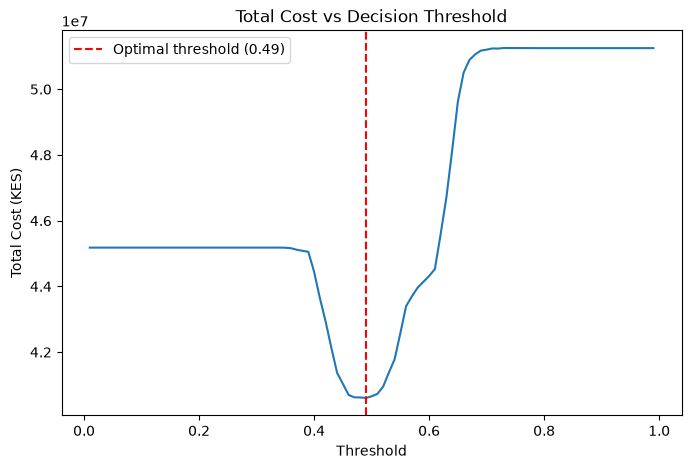

In [18]:
import matplotlib.pyplot as plt
# Save the cost-vs-threshold plot as an image file, for inclusion in the repo
plt.figure(figsize=(8, 5))
plt.plot(results_df['threshold'], results_df['total_cost'])
plt.xlabel('Threshold')
plt.ylabel('Total Cost (KES)')
plt.title('Total Cost vs Decision Threshold')
plt.axvline(x=0.49, color='red', linestyle='--', label='Optimal threshold (0.49)')
plt.legend()

# Create a "results" folder to keep all the plots organised
import os
os.makedirs('../results', exist_ok=True)
plt.savefig('../results/cost_threshold_curve.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
# Get the row from our results table specifically at threshold = 0.50 (the naive default)
naive_row = results_df[results_df['threshold'].round(2) == 0.50].iloc[0]

# Compare costs
optimal_cost = best_row['total_cost']
naive_cost = naive_row['total_cost']
savings = naive_cost - optimal_cost

# Scale the savings down to "per 1,000 applications" as the assignment asks
total_transactions = len(all_true_labels)
savings_per_1000 = (savings / total_transactions) * 1000

print(f"Naive (0.5) total cost: KES {naive_cost:,.0f}")
print(f"Optimal (0.49) total cost: KES {optimal_cost:,.0f}")
print(f"Savings: KES {savings:,.0f}")
print(f"Savings per 1,000 applications: KES {savings_per_1000:,.2f}")

Naive (0.5) total cost: KES 40,656,000
Optimal (0.49) total cost: KES 40,604,000
Savings: KES 52,000
Savings per 1,000 applications: KES 844.16


# 4. IMBALANCE HANDLING

In [20]:
from imblearn.over_sampling import SMOTE

# Grab Fold 1 again, same as our very first single-fold test
fold1 = folds[0]
X_train = df_final[fold1['train_mask']]
X_test = df_final[fold1['test_mask']]
y_train = df_final.loc[fold1['train_mask'], target]
y_test = df_final.loc[fold1['test_mask'], target]

# --- THE WRONG WAY: apply SMOTE to the FULL dataset (train+test combined) BEFORE splitting ---
# this mistake is simulated by fitting SMOTE using information across both sets combined,
# then only training on what we call "train"  but the synthetic points were influenced by test data too

# First, preprocess the raw features into pure numbers (SMOTE needs numeric input only)
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Combine train+test numeric data together (the mistake: SMOTE will "see" test data patterns)
import scipy.sparse as sp
X_combined = sp.vstack([X_train_processed, X_test_processed]) if sp.issparse(X_train_processed) else np.vstack([X_train_processed, X_test_processed])
y_combined = pd.concat([y_train, y_test])

# Apply SMOTE to the COMBINED data (this is the leakage mistake)
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_combined, y_combined)

# Now pretend that only the first part (original train size) is our "training set"
n_train_original = X_train_processed.shape[0]
# Since SMOTE inserts synthetic samples mixed in,an  approximation is made by just taking resampled data 
# proportional to train for demonstration and  ALL resampled data will be trained (the wrong approach)
from sklearn.linear_model import LogisticRegression
wrong_model = LogisticRegression(max_iter=1000)
wrong_model.fit(X_resampled, y_resampled)

# Test on the ORIGINAL (unprocessed-by-SMOTE) test set
y_pred_proba_wrong = wrong_model.predict_proba(X_test_processed)[:, 1]
wrong_pr_auc = average_precision_score(y_test, y_pred_proba_wrong)

print(f"WRONG approach (SMOTE before split) - PR-AUC: {wrong_pr_auc:.4f}")

WRONG approach (SMOTE before split) - PR-AUC: 0.1103


In [21]:
# --- THE CORRECT WAY: applying SMOTE ONLY to the training set, never touching test data ---

# X_train_processed and y_train  are ONLY training rows and they are already available
# Apply SMOTE fitted purely on training data (test data never involved at all)
smote_correct = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote_correct.fit_resample(X_train_processed, y_train)

# Train a fresh model on this properly-resampled TRAINING data only
correct_model = LogisticRegression(max_iter=1000)
correct_model.fit(X_train_resampled, y_train_resampled)

# Test on the SAME original test set as before, for a fair comparison
y_pred_proba_correct = correct_model.predict_proba(X_test_processed)[:, 1]
correct_pr_auc = average_precision_score(y_test, y_pred_proba_correct)

print(f"CORRECT approach (SMOTE only on train) - PR-AUC: {correct_pr_auc:.4f}")
print(f"\nComparison:")
print(f"WRONG (leaked): {wrong_pr_auc:.4f}")
print(f"CORRECT (safe): {correct_pr_auc:.4f}")
print(f"Inflation from leakage: {wrong_pr_auc - correct_pr_auc:.4f}")

CORRECT approach (SMOTE only on train) - PR-AUC: 0.1078

Comparison:
WRONG (leaked): 0.1103
CORRECT (safe): 0.1078
Inflation from leakage: 0.0025


In [22]:
# This will store SMOTE's PR-AUC score from each of the 6 folds, for fair comparison
# against the class-weighted Logistic Regression scores from Point 2 (0.118 mean, 0.0049 std)

smote_scores = []

for fold in folds:
    X_train = df_final[fold['train_mask']]
    X_test = df_final[fold['test_mask']]
    y_train = df_final.loc[fold['train_mask'], target]
    y_test = df_final.loc[fold['test_mask'], target]
    
    # Preprocess this fold's data into pure numbers (fit ONLY on this fold's training data)
    X_train_proc = preprocessor.fit_transform(X_train)
    X_test_proc = preprocessor.transform(X_test)
    
    # Apply SMOTE ONLY to this fold's training data (never touching test data)
    smote = SMOTE(random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train_proc, y_train)
    
    # Train a plain Logistic Regression (no class_weight needed - SMOTE already balanced the data)
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train_res, y_train_res)
    
    # Test on the original, untouched test data
    y_pred_proba = model.predict_proba(X_test_proc)[:, 1]
    pr_auc = average_precision_score(y_test, y_pred_proba)
    smote_scores.append(pr_auc)
    
    print(f"Fold testing on {fold['test_month']}: PR-AUC = {pr_auc:.4f}")

print(f"\nMean PR-AUC (SMOTE): {np.mean(smote_scores):.4f}")
print(f"Std across folds: {np.std(smote_scores):.4f}")

Fold testing on 2026-02: PR-AUC = 0.1078
Fold testing on 2026-03: PR-AUC = 0.1168
Fold testing on 2026-04: PR-AUC = 0.1221
Fold testing on 2026-05: PR-AUC = 0.1225
Fold testing on 2026-06: PR-AUC = 0.1158
Fold testing on 2026-07: PR-AUC = 0.1140

Mean PR-AUC (SMOTE): 0.1165
Std across folds: 0.0050


# 5. OPTUNA TUNING

In [23]:
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner

# Tuning will be done using just 2 spaced-out folds (index 2 and 5) instead of all 6,
tuning_folds = [folds[2], folds[5]]

def objective(trial):
    # Define the SEARCH SPACE: the ranges of settings Optuna is allowed to try
    params = {
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 100, 400),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 5),
    }
    
    fold_scores = []
    
    # Check this trial's settings against our 2 chosen folds, one at a time
    for i, fold in enumerate(tuning_folds):
        X_train = df_final[fold['train_mask']]
        X_test = df_final[fold['test_mask']]
        y_train = df_final.loc[fold['train_mask'], target]
        y_test = df_final.loc[fold['test_mask'], target]
        
        # Calculate this fold's own imbalance ratio (same leakage-safe approach as before)
        scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
        
        # Build and train XGBoost with THIS trial's specific settings
        model = Pipeline([
            ('prep', preprocessor_xgb),
            ('clf', XGBClassifier(**params, scale_pos_weight=scale_pos_weight,
                                    random_state=42, eval_metric='aucpr', n_jobs=-1))
        ])
        model.fit(X_train, y_train)
        y_pred = model.predict_proba(X_test)[:, 1]
        score = average_precision_score(y_test, y_pred)
        fold_scores.append(score)
        
        # Report progress after each fold, so Optuna can decide whether to prune (stop early)
        trial.report(np.mean(fold_scores), step=i)
        if trial.should_prune():
            raise optuna.TrialPruned()
    
    # Return the average score across both tuning folds 
    return np.mean(fold_scores)

# Create the study: maximize PR-AUC, use a smart sampler (TPE), and prune weak trials early
# Saved to a database file so it can be reloaded later 
study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=42),
    pruner=MedianPruner(n_warmup_steps=0),
    storage='sqlite:///../results/optuna_study.db',
    study_name='xgb_tuning',
    load_if_exists=True
)

# Run 60 trials 
study.optimize(objective, n_trials=60)

print("Best PR-AUC found:", study.best_value)
print("Best parameters:", study.best_params)

[I 2026-09-06 07:16:17,745] Using an existing study with name 'xgb_tuning' instead of creating a new one.
[I 2026-09-06 07:16:19,964] Trial 60 pruned. 
[I 2026-09-06 07:16:25,302] Trial 61 finished with value: 0.11946974578494701 and parameters: {'max_depth': 4, 'learning_rate': 0.05220107658783707, 'n_estimators': 207, 'subsample': 0.617786270072064, 'colsample_bytree': 0.737523467097965, 'min_child_weight': 5, 'gamma': 4.479446694087331}. Best is trial 37 with value: 0.11993480641496604.
[I 2026-09-06 07:16:27,740] Trial 62 pruned. 
[I 2026-09-06 07:16:30,319] Trial 63 pruned. 
[I 2026-09-06 07:16:33,279] Trial 64 pruned. 
[I 2026-09-06 07:16:37,812] Trial 65 finished with value: 0.11839896511073872 and parameters: {'max_depth': 4, 'learning_rate': 0.08280601231551932, 'n_estimators': 189, 'subsample': 0.7460634830330358, 'colsample_bytree': 0.764573294491251, 'min_child_weight': 9, 'gamma': 3.958752430979614}. Best is trial 37 with value: 0.11993480641496604.
[I 2026-09-06 07:16:40,

Best PR-AUC found: 0.12059000307536452
Best parameters: {'max_depth': 4, 'learning_rate': 0.03758577020501512, 'n_estimators': 128, 'subsample': 0.6004994742304696, 'colsample_bytree': 0.6725361890181225, 'min_child_weight': 2, 'gamma': 2.7452862386589247}


In [24]:
# Using the best parameters Optuna found, and test them properly across ALL 6 folds
# (not just the 2 folds used during the search, for an honest final evaluation)

best_params = study.best_params

tuned_xgb_scores = []

for fold in folds:
    X_train = df_final[fold['train_mask']]
    X_test = df_final[fold['test_mask']]
    y_train = df_final.loc[fold['train_mask'], target]
    y_test = df_final.loc[fold['test_mask'], target]
    
    # Same leakage-safe imbalance ratio calculation as before
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
    
    # Build XGBoost using Optuna's best-found settings
    tuned_model = Pipeline([
        ('prep', preprocessor_xgb),
        ('clf', XGBClassifier(**best_params, scale_pos_weight=scale_pos_weight,
                                random_state=42, eval_metric='aucpr', n_jobs=-1))
    ])
    
    tuned_model.fit(X_train, y_train)
    y_pred_proba = tuned_model.predict_proba(X_test)[:, 1]
    pr_auc = average_precision_score(y_test, y_pred_proba)
    tuned_xgb_scores.append(pr_auc)
    
    print(f"Fold testing on {fold['test_month']}: PR-AUC = {pr_auc:.4f}")

print(f"\nMean PR-AUC (Tuned XGBoost): {np.mean(tuned_xgb_scores):.4f}")
print(f"Std across folds: {np.std(tuned_xgb_scores):.4f}")
print(f"\nComparison to untuned XGBoost: 0.1050 -> {np.mean(tuned_xgb_scores):.4f}")

Fold testing on 2026-02: PR-AUC = 0.1080
Fold testing on 2026-03: PR-AUC = 0.1177
Fold testing on 2026-04: PR-AUC = 0.1264
Fold testing on 2026-05: PR-AUC = 0.1226
Fold testing on 2026-06: PR-AUC = 0.1192
Fold testing on 2026-07: PR-AUC = 0.1148

Mean PR-AUC (Tuned XGBoost): 0.1181
Std across folds: 0.0058

Comparison to untuned XGBoost: 0.1050 -> 0.1181


C:\Users\dsimiyu\AppData\Local\Temp\ipykernel_22120\1032388875.py:2: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  fig = optuna.visualization.matplotlib.plot_optimization_history(study)


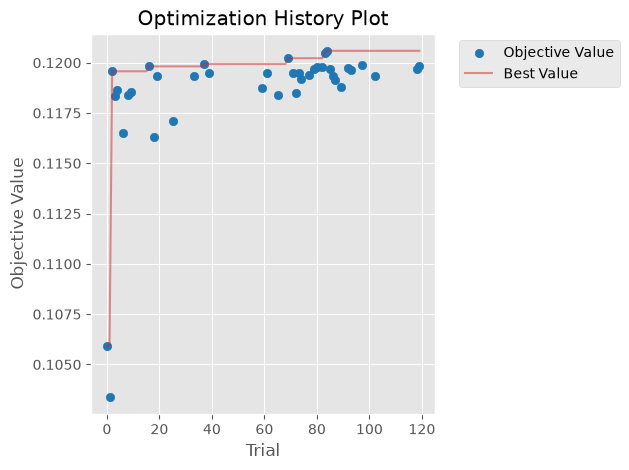

In [25]:
# Plot how the score improved across all 60 trials
fig = optuna.visualization.matplotlib.plot_optimization_history(study)
plt.savefig('../results/optuna_history.png', dpi=150, bbox_inches='tight')
plt.show()

# 6. CALIBRATION

In [26]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

# Brier score: measures how far off predicted probabilities are from reality
# lower is better - 0 would mean perfect probability predictions
brier_before = brier_score_loss(all_true_labels, all_predicted_probs)

# calibration_curve groups predictions into 10 "bins" (e.g. all predictions around 0.3),
# then checks: within each bin, what fraction ACTUALLY turned out to be fraud?
# If well-calibrated, predicted probability should roughly match actual fraud rate
prob_true, prob_pred = calibration_curve(all_true_labels, all_predicted_probs, n_bins=10)

print(f"Brier score (uncalibrated): {brier_before:.4f}")

Brier score (uncalibrated): 0.2423


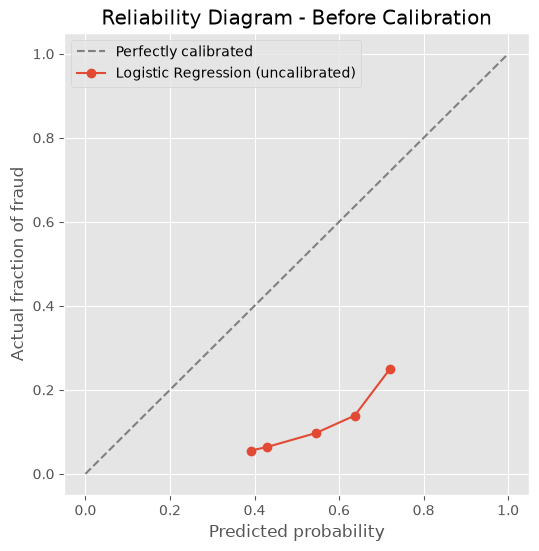

In [27]:
# A perfectly calibrated model would sit exactly on the diagonal dashed line
plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly calibrated')
plt.plot(prob_pred, prob_true, marker='o', label='Logistic Regression (uncalibrated)')
plt.xlabel('Predicted probability')
plt.ylabel('Actual fraction of fraud')
plt.title('Reliability Diagram - Before Calibration')
plt.legend()
plt.savefig('../results/reliability_before.png', dpi=150, bbox_inches='tight')
plt.show()

In [28]:
from sklearn.calibration import CalibratedClassifierCV

# Refit Logistic Regression using Platt calibration (sigmoid method)
# cv=5 means it uses 5 internal folds of the TRAINING data to learn the correction,
# Test data is not leaked into the calibration step either
calibrated_model = CalibratedClassifierCV(logreg_pipeline, method='sigmoid', cv=5)

# Fit and evaluate this across all 6 folds, same pattern as before,
# collecting pooled predictions again (needed for the new reliability diagram + Brier score)
all_true_calibrated = []
all_predicted_calibrated = []

for fold in folds:
    X_train = df_final[fold['train_mask']]
    X_test = df_final[fold['test_mask']]
    y_train = df_final.loc[fold['train_mask'], target]
    y_test = df_final.loc[fold['test_mask'], target]
    
    calibrated_model.fit(X_train, y_train)
    y_pred_proba = calibrated_model.predict_proba(X_test)[:, 1]
    
    all_true_calibrated.extend(y_test.tolist())
    all_predicted_calibrated.extend(y_pred_proba.tolist())

all_true_calibrated = np.array(all_true_calibrated)
all_predicted_calibrated = np.array(all_predicted_calibrated)

# Recalculate Brier score and the reliability curve, now using calibrated probabilities
brier_after = brier_score_loss(all_true_calibrated, all_predicted_calibrated)
prob_true_after, prob_pred_after = calibration_curve(all_true_calibrated, all_predicted_calibrated, n_bins=10)

print(f"Brier score (BEFORE calibration): {brier_before:.4f}")
print(f"Brier score (AFTER calibration): {brier_after:.4f}")

Brier score (BEFORE calibration): 0.2423
Brier score (AFTER calibration): 0.0755


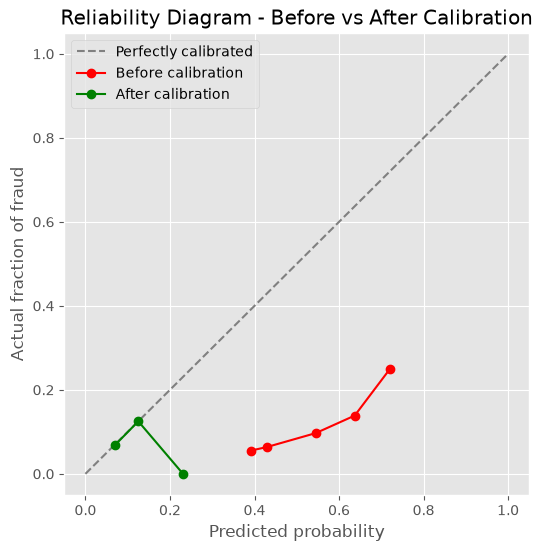

In [29]:
# Plot the AFTER calibration reliability diagram, side by side comparison
plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly calibrated')
plt.plot(prob_pred, prob_true, marker='o', label='Before calibration', color='red')
plt.plot(prob_pred_after, prob_true_after, marker='o', label='After calibration', color='green')
plt.xlabel('Predicted probability')
plt.ylabel('Actual fraction of fraud')
plt.title('Reliability Diagram - Before vs After Calibration')
plt.legend()
plt.savefig('../results/reliability_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [30]:
# Same threshold-sweep logic as Point 3, but using calibrated probabilities this time
thresholds_to_test = np.arange(0.01, 1.00, 0.01)
results_calibrated = []

for t in thresholds_to_test:
    predicted_fraud = (all_predicted_calibrated >= t).astype(int)
    false_negatives = ((predicted_fraud == 0) & (all_true_calibrated == 1)).sum()
    false_positives = ((predicted_fraud == 1) & (all_true_calibrated == 0)).sum()
    total_cost = (false_negatives * COST_MISSED_FRAUD) + (false_positives * COST_FALSE_ALARM)
    results_calibrated.append({'threshold': t, 'total_cost': total_cost})

results_calibrated_df = pd.DataFrame(results_calibrated)
best_calibrated_row = results_calibrated_df.loc[results_calibrated_df['total_cost'].idxmin()]

print("NEW optimal threshold (after calibration):")
print(best_calibrated_row)
print(f"\nOriginal threshold (before calibration): 0.49")

NEW optimal threshold (after calibration):
threshold            0.08
total_cost    40611200.00
Name: 7, dtype: float64

Original threshold (before calibration): 0.49


In [31]:
# Compare the actual money cost between the old (uncalibrated) and new (calibrated) optimal thresholds
print(f"Old optimal (0.49, uncalibrated): KES {best_row['total_cost']:,.0f}")
print(f"New optimal (0.08, calibrated): KES {best_calibrated_row['total_cost']:,.0f}")

Old optimal (0.49, uncalibrated): KES 40,604,000
New optimal (0.08, calibrated): KES 40,611,200


# 7. EXPLAINABILITY (SHAP) & Fairness

Background dataset has 10283 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=10283 when initializing the masker.


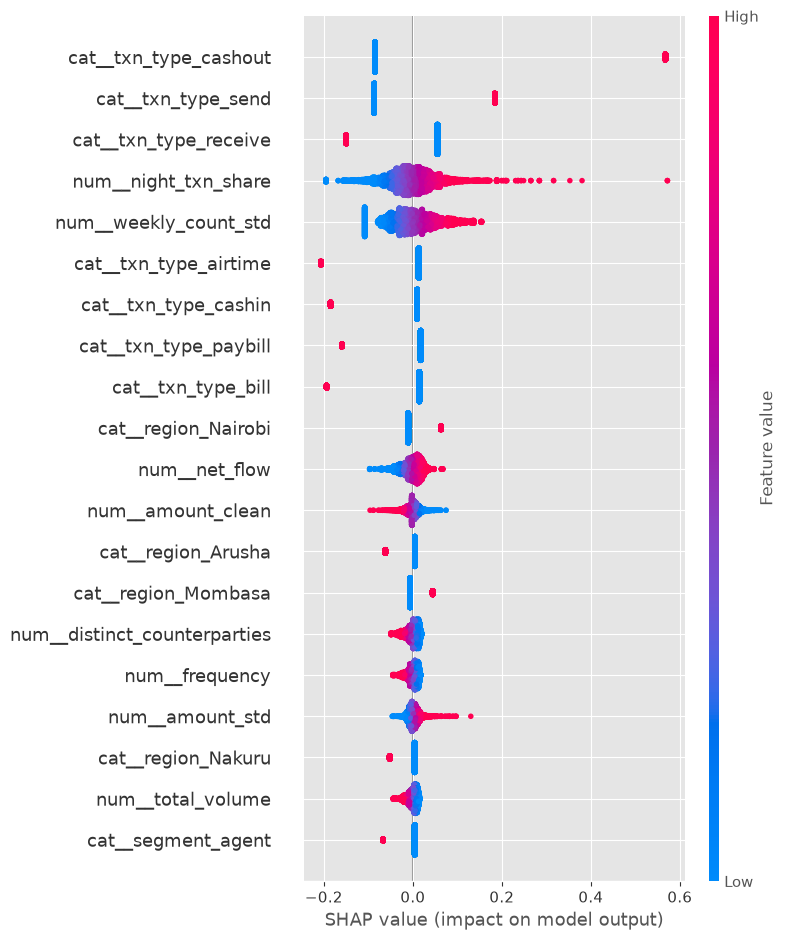

In [32]:
import shap

# Use the last fold (testing on July) as our example dataset for explanations
last_fold = folds[-1]
X_train = df_final[last_fold['train_mask']]
X_test = df_final[last_fold['test_mask']]
y_train = df_final.loc[last_fold['train_mask'], target]

# Refit Logistic Regression on this fold's training data (for a consistent, up-to-date model)
logreg_pipeline.fit(X_train, y_train)

# Convert the raw test data into the same numeric format the model actually sees
# (after imputation, scaling, and one-hot encoding)
X_test_processed = logreg_pipeline.named_steps['prep'].transform(X_test)
feature_names = logreg_pipeline.named_steps['prep'].get_feature_names_out()

# LinearExplainer computes EXACT SHAP values quickly, since our model is linear
explainer = shap.LinearExplainer(logreg_pipeline.named_steps['clf'], X_test_processed)
shap_values = explainer(X_test_processed)

# GLOBAL explanation: which features matter most, on average, across all July transactions
shap.summary_plot(shap_values, X_test_processed, feature_names=feature_names, show=False)
plt.savefig('../results/shap_global.png', dpi=150, bbox_inches='tight')
plt.show()

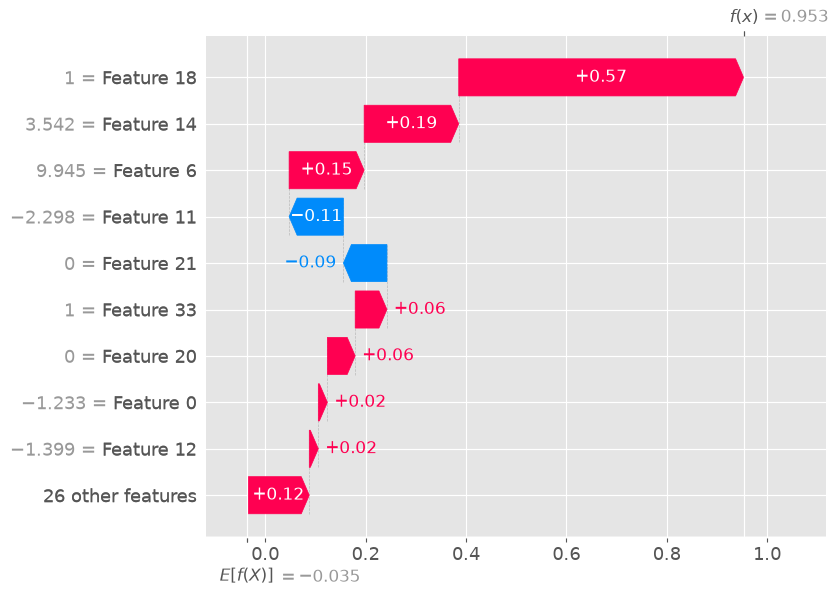

In [33]:
# Pick the transaction the model was MOST confident was fraud, as an interesting example to explain
idx = np.argmax(logreg_pipeline.predict_proba(X_test)[:, 1])

# LOCAL explanation: exactly which features drove THIS one prediction
shap.plots.waterfall(shap_values[idx], show=False)
plt.savefig('../results/shap_local_example.png', dpi=150, bbox_inches='tight')
plt.show()

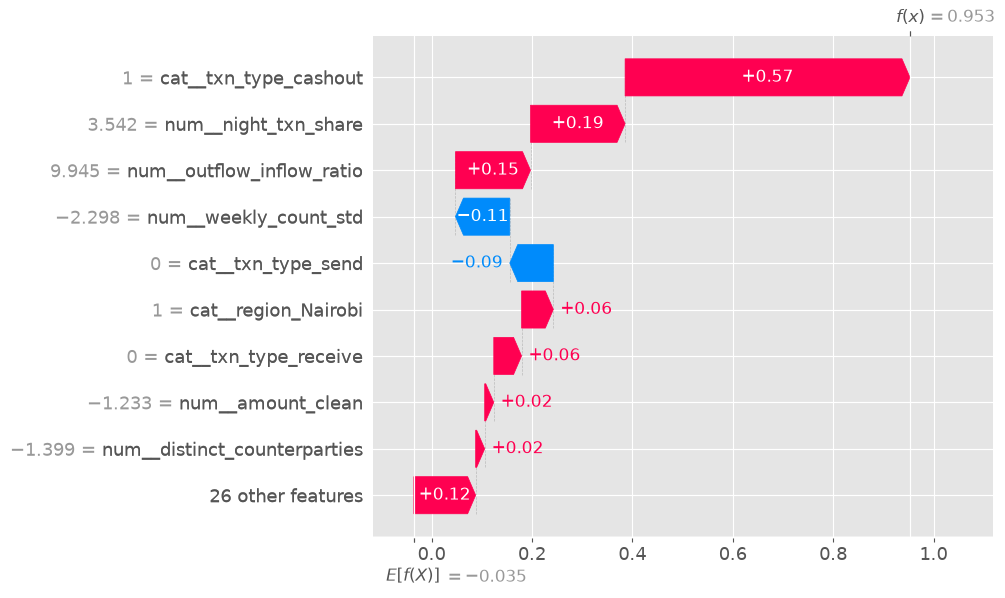

In [35]:
# Pick the transaction the model was MOST confident was fraud, as an interesting example to explain
idx = np.argmax(logreg_pipeline.predict_proba(X_test)[:, 1])

# Attach the real feature names to the SHAP values object, so plots show
# actual names instead of generic "Feature 18", "Feature 14", etc.
shap_values.feature_names = list(feature_names)

# LOCAL explanation: exactly which features drove THIS one prediction
shap.plots.waterfall(shap_values[idx], show=False)
plt.savefig('../results/shap_local_example.png', dpi=150, bbox_inches='tight')
plt.show()